<a href="https://colab.research.google.com/github/arushikhangar/Session-16/blob/main/Session16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv("/content/insurance.csv")

Question 01

In [6]:
df.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


Question 02

In [10]:
print("Shape")
df.shape

Shape


(1338, 7)

In [11]:
print("Column Name and Datatypes")
df.info()

Column Name and Datatypes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [12]:
print("Statistical Summary")
df.describe()

Statistical Summary


,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


Question 03

In [14]:
print("count of null values for each column")
df.isnull().sum()

count of null values for each column


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


Question 04

In [20]:
print("categorical columns")
for col in df.columns:
  if df[col].dtype == "object":
    print(df[col])

categorical columns
0       female
1         male
2         male
3         male
4         male
         ...  
1333      male
1334    female
1335    female
1336    female
1337    female
Name: sex, Length: 1338, dtype: object
0       yes
1        no
2        no
3        no
4        no
       ... 
1333     no
1334     no
1335     no
1336     no
1337    yes
Name: smoker, Length: 1338, dtype: object
0       southwest
1       southeast
2       southeast
3       northwest
4       northwest
          ...    
1333    northwest
1334    northeast
1335    southeast
1336    southwest
1337    northwest
Name: region, Length: 1338, dtype: object


In [30]:
print("numerical columns")
for col in df.columns:
  if df[col].dtype in ["int64", "float64"]:
    print(df[col])

numerical columns
0       19
1       18
2       28
3       33
4       32
        ..
1333    50
1334    18
1335    18
1336    21
1337    61
Name: age, Length: 1338, dtype: int64
0       27.9
1       33.8
2       33.0
3       22.7
4       28.9
        ... 
1333    31.0
1334    31.9
1335    36.9
1336    25.8
1337    29.1
Name: bmi, Length: 1338, dtype: float64
0       0
1       1
2       3
3       0
4       0
       ..
1333    3
1334    0
1335    0
1336    0
1337    0
Name: children, Length: 1338, dtype: int64
0       16884.92
1        1725.55
2        4449.46
3       21984.47
4        3866.86
          ...   
1333    10600.55
1334     2205.98
1335     1629.83
1336     2007.95
1337    29141.36
Name: expenses, Length: 1338, dtype: float64


Question 05

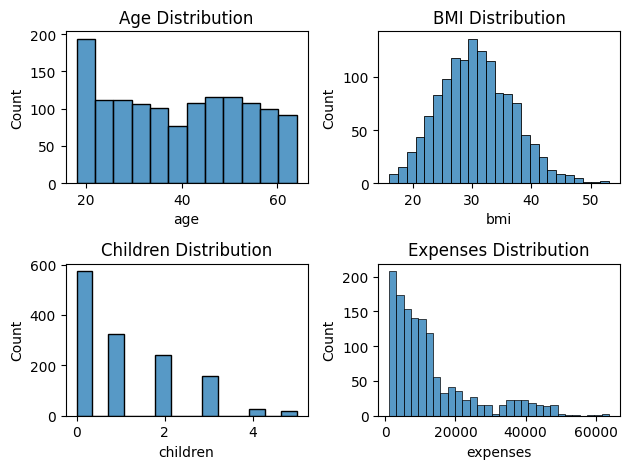

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplot(2, 2, 1)
sns.histplot(df['age'])
plt.title("Age Distribution")

plt.subplot(2, 2, 2)
sns.histplot(df['bmi'])
plt.title("BMI Distribution")

plt.subplot(2, 2, 3)
sns.histplot(df['children'])
plt.title("Children Distribution")

plt.subplot(2, 2, 4)
sns.histplot(df['expenses'])
plt.title("Expenses Distribution")


plt.tight_layout()


Question 06

Text(0.5, 1.0, 'Sex Count')

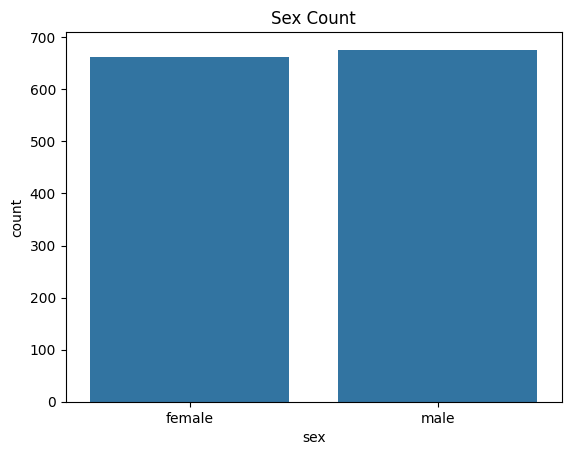

In [60]:
sns.countplot(x='sex', data=df)
plt.title("Sex Count")

Text(0.5, 1.0, 'Smoker Count')

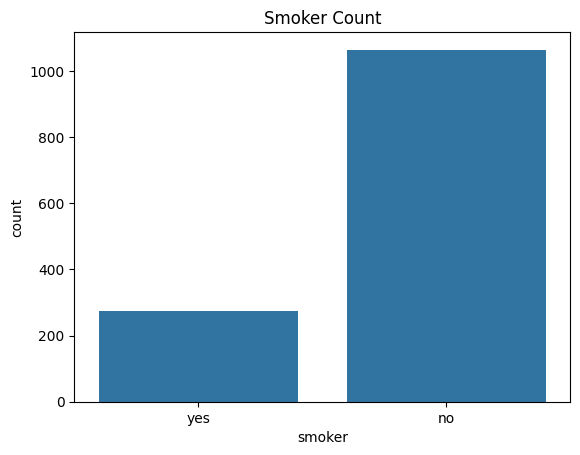

In [61]:
sns.countplot(x='smoker', data=df)
plt.title("Smoker Count")

Text(0.5, 1.0, 'Region Count')

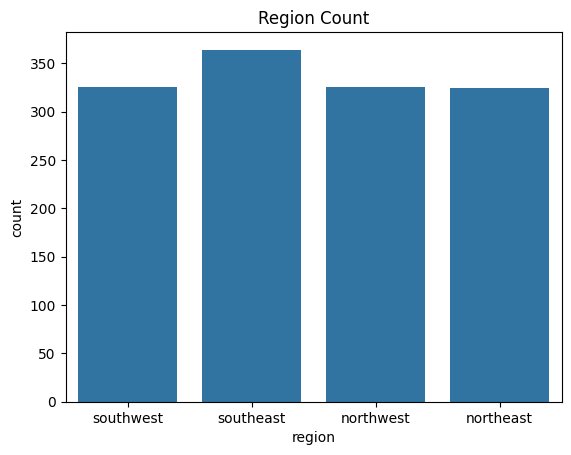

In [62]:
sns.countplot(x='region', data=df)
plt.title("Region Count")

Question 07

<Axes: >

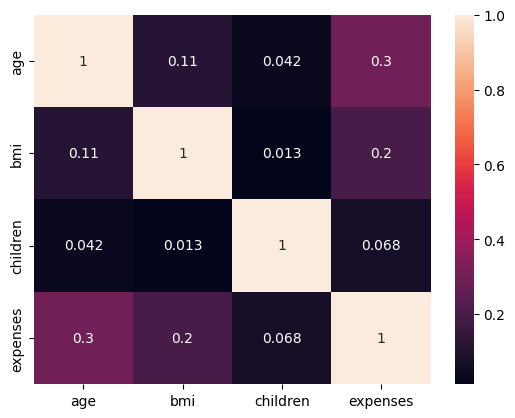

In [66]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

Question 08

In [85]:
from itertools import groupby
print("Average Charges : ", df['expenses'].mean())
print("Maximum Charges : ", df['expenses'].max())
print("Minimum Charges : ", df['expenses'].min())
new_var = 'smoker'
print("Average Charges for Smoker:\n", df.groupby('smoker')['expenses'].mean())


Average Charges :  13270.422414050823
Maximum Charges :  63770.43
Minimum Charges :  1121.87
Average Charges for Smoker:
 smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


Question 09

Text(0.5, 1.0, 'Charges by Sex and Smoker')

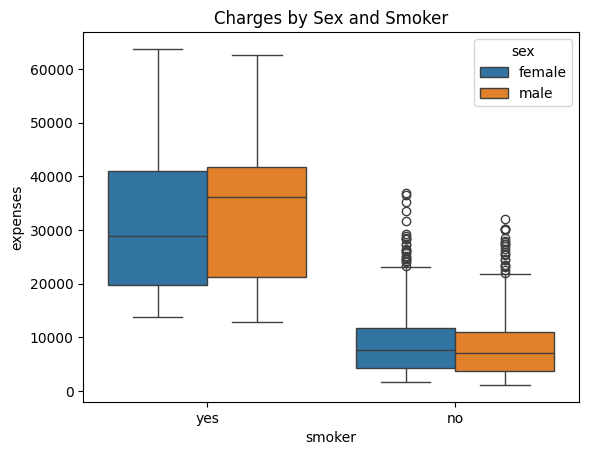

In [104]:
sns.boxplot(x='smoker', y='expenses', hue='sex', data=df)
plt.title("Charges by Sex and Smoker")

Question 10

1. What is the average age and BMI of the customers? -> The average age 39 years and The average BMI 30.7

2. How does smoking affect insurance charges? -> Smokers consistently pay much higher expenses compared to non-smokers.

3. Which region has the highest number of customers? ->.The region with the highest number of customers is the Southeast.

4. Any interesting observations from the visualizations? -> Smoking increases insurance charges, while region and sex play smaller roles. smokers have much higher median expenses than non-smokers.